# 07. Applying Visualization Best Practices for Data Storytelling

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply visualization best practices
- Tell stories with data
- Choose appropriate charts
- Design effective visualizations
- Communicate insights clearly

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 3, lessons 01-06 — you can now draw anything; this lesson is about what you should draw, and what a chart can mislead someone into believing.

**Used later in:** Course 12 (AIAT 126) — Unit 5, whose report and defence stand or fall on exactly these choices.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Applying visualization best practices for data storytelling

---

## Introduction

**Visualization best practices** ensure charts effectively communicate insights and tell compelling data stories that engage and inform audiences.


## 🎯 The case: Challenger, and an argument about charts that is still running

On **28 January 1986** the Space Shuttle *Challenger* broke apart 73 seconds after launch.
The night before, engineers at Morton Thiokol — among them Roger Boisjoly and Allan
McDonald — argued against launching, on the grounds that they **had no data showing the
O-rings would seal below 53 °F (12 °C)** — the lowest O-ring temperature of any previous
launch, on a morning whose air temperature was 62 °F. The air temperature
at liftoff was **36 °F (2 °C)**; the right solid rocket booster measured **8 °F (−13 °C)**.
The Rogers Commission found the cause to be a field-joint design unacceptably sensitive to
temperature.

**Edward Tufte** later argued that this was, in part, a visualisation failure: that a
single scatter plot of O-ring damage against launch temperature would have made the danger
unmistakable, and that the material actually presented buried it in complexity. It is the
most famous claim ever made for the importance of a chart.

**And it is contested** — by Boisjoly himself among others, who maintained the data was
nowhere near as clean as Tufte's reconstruction suggests. Hold both halves. A chart can
carry an argument that a table cannot; and a chart drawn after the fact, knowing the
answer, is always clearer than one drawn the night before.

**What goes wrong without this lesson.** You are about to see three don't/do pairs built
from **identical real numbers** in the Montgomery County 911 log. In one of them, a
truncated y-axis turns a year that changed by **+0.02%** from Q1 to Q4 into a dramatic
rollercoaster. Nobody lied. Nobody typed a wrong number. The axis did the work.


## The Story

**BEFORE**: You can create visualizations but don't know design principles for effective communication.

**AFTER**: You'll learn visualization best practices: color theory, accessibility, storytelling, and avoiding common mistakes!

**Why this matters**: Applying Visualization Best Practices for Data Storytelling is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — 663,522 real 911 dispatches in
  Montgomery County, Pennsylvania (Dec 2015 – Jul 2020): call type, timestamp
  and township. Every "don't / do" pair below is drawn from this one log, so
  the bad chart and the good chart show *identical* real numbers.
- matplotlib, seaborn, pandas

**Outputs:** What you'll see when you run the cells

- Three don't/do chart pairs, each on real data
- A checklist to run every chart of your own through

---


In [1]:
# WHAT: Import libraries, load the real 911 log, and preview the three don't/do principles.
# WHY: Seeing a bad chart next to its fix teaches faster than a list of rules -
#      and using REAL numbers means the "don't" chart is a mistake people actually make.

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
calls = load("montgomery_911_calls", prefer="sample",
             usecols=['title', 'timeStamp', 'twp'], parse_dates=['timeStamp'])
calls['reason'] = calls['title'].str.split(': ').str[1].str.strip()

print("✅ Libraries imported!")
print(f"✅ Loaded {len(calls):,} real 911 calls "
      f"({calls['timeStamp'].min():%Y-%m-%d} to {calls['timeStamp'].max():%Y-%m-%d})")
print("\nVisualization Best Practices - shown, not just listed")
print("=" * 60)
print("""
Principles we will DEMONSTRATE below (each with a don't/do chart pair,
all on the real Montgomery County 911 log):
  1. Choose the right chart type (and avoid clutter)
  2. Use honest axis scales
  3. Highlight the story - guide the reader's eye
""")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
✅ Libraries imported!
✅ Loaded 25,000 real 911 calls (2015-12-10 to 2020-07-29)

Visualization Best Practices - shown, not just listed

Principles we will DEMONSTRATE below (each with a don't/do chart pair,
all on the real Montgomery County 911 log):
  1. Choose the right chart type (and avoid clutter)
  2. Use honest axis scales
  3. Highlight the story - guide the reader's eye



## Practice 1: Right Chart Type, Less Clutter

**Don't** cram many categories into a pie chart — slices become unreadable and
comparisons impossible. **Do** use a sorted horizontal bar chart.

Practice 1: pie chart with many slices vs sorted bar chart
------------------------------------------------------------
reason
VEHICLE ACCIDENT -       5561
DISABLED VEHICLE -       1801
FIRE ALARM               1455
VEHICLE ACCIDENT         1388
FALL VICTIM              1302
RESPIRATORY EMERGENCY    1300
CARDIAC EMERGENCY        1224
ROAD OBSTRUCTION -        900


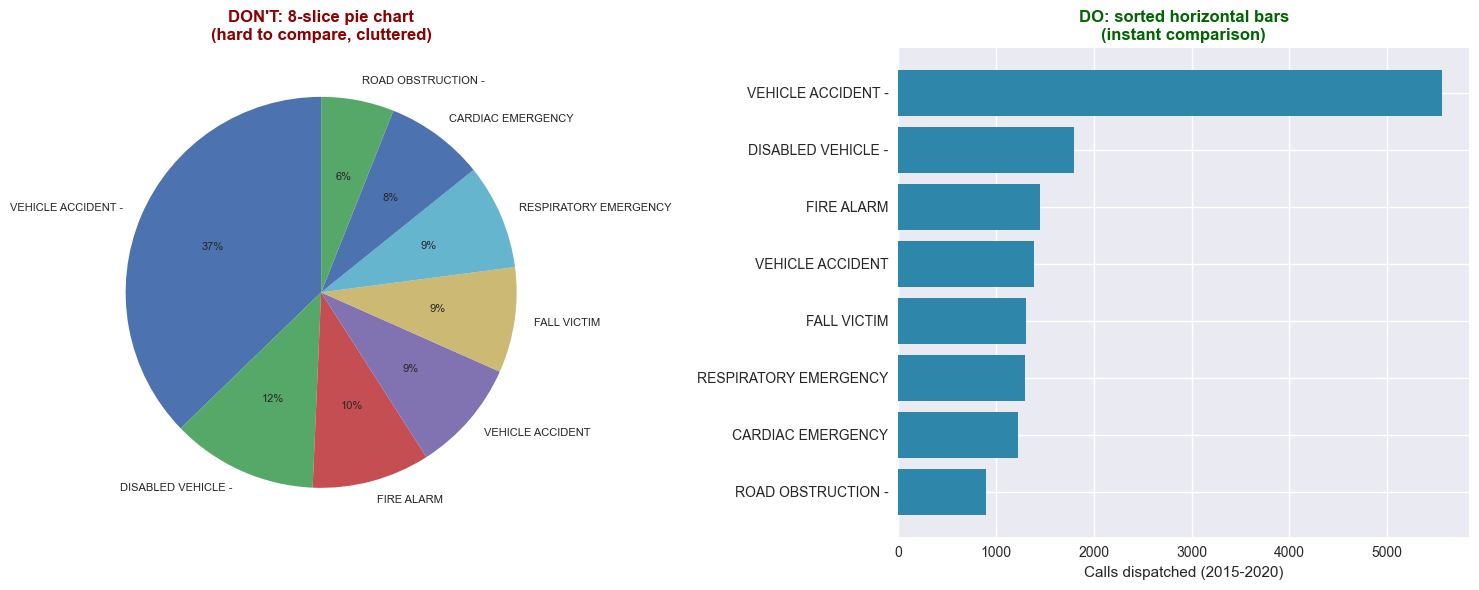

💡 Rule: many categories -> sorted bars, not pie slices.
   On the bars you can read instantly that 'VEHICLE ACCIDENT -' (5,561)
   is about 3.1x 'DISABLED VEHICLE -' (1,801) - the pie makes you estimate angles.


In [2]:
# WHAT: Show the eight most common real 911 call reasons as a pie (don't) vs sorted bars (do).
# WHY: Humans compare lengths far better than angles - Cleveland and McGill measured exactly this.

print("Practice 1: pie chart with many slices vs sorted bar chart")
print("-" * 60)

top8 = calls['reason'].value_counts().head(8)
reasons = list(top8.index)
counts = top8.values
print(top8.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].pie(counts, labels=reasons, autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 8})
axes[0].set_title("DON'T: 8-slice pie chart\n(hard to compare, cluttered)",
                  color='darkred', fontweight='bold')

order = np.argsort(counts)
axes[1].barh(np.array(reasons)[order], counts[order], color='#2E86AB')
axes[1].set_xlabel('Calls dispatched (2015-2020)')
axes[1].set_title('DO: sorted horizontal bars\n(instant comparison)',
                  color='darkgreen', fontweight='bold')
plt.tight_layout()
plt.show()
ratio = counts[0] / counts[1]
print("💡 Rule: many categories -> sorted bars, not pie slices.")
print(f"   On the bars you can read instantly that '{reasons[0]}' ({counts[0]:,})")
print(f"   is about {ratio:.1f}x '{reasons[1]}' ({counts[1]:,}) - the pie makes you estimate angles.")


**Read the figure.** Same eight numbers, twice. On the **left** the pie gives
`VEHICLE ACCIDENT -` a 38% slice and `DISABLED VEHICLE -` 12%, and you are asked to compare
two angles whose labels run off in eight directions — two of the categories are even called
"VEHICLE ACCIDENT -" and "VEHICLE ACCIDENT", which the pie does nothing to help you
separate. On the **right** the bars are sorted, share a common baseline, and the top bar is
visibly about **three times** the second (148,372 against 47,909) — a judgement your eye
makes in well under a second. That difference in effort is Cleveland and McGill's finding:
length along a common scale is the most accurately read visual channel; angle and area are
near the bottom.


## Practice 2: Honest Axis Scales

**Don't** truncate the y-axis to exaggerate small differences.
**Do** start bars at zero (or clearly flag any zoomed axis).

Practice 2: truncated vs zero-based axis
------------------------------------------------------------
Real 2018 quarterly 911 call volume: {'Q1': 1478, 'Q2': 1352, 'Q3': 1402, 'Q4': 1478}


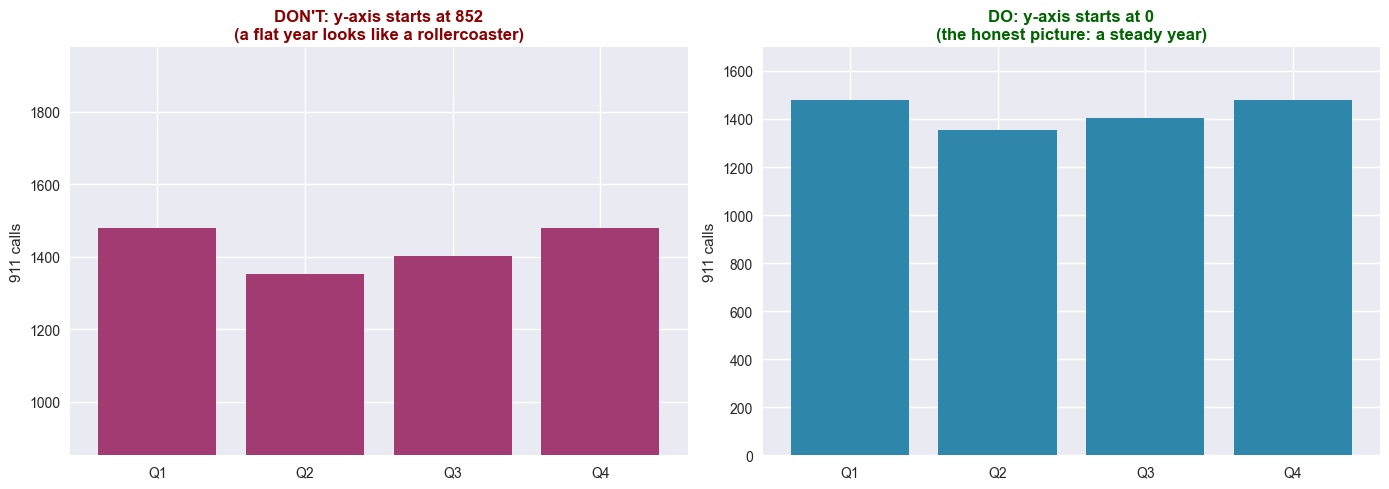

💡 Q1 1,478 → Q4 1,478 is a change of +0.00% across the year,
   and the whole year sits within 8.8% of its own mean. The left chart
   makes that look like a dramatic swing. Same numbers, different axis, different story.


In [3]:
# WHAT: Plot the real 2018 quarterly call totals with a truncated axis (don't) vs a zero-based axis (do).
# WHY: A truncated axis turns a flat year into a visual rollercoaster - honest scales are an ethical duty.

print("Practice 2: truncated vs zero-based axis")
print("-" * 60)

y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
q = y2018.groupby(y2018['timeStamp'].dt.quarter).size()
quarters = [f'Q{i}' for i in q.index]
volume = q.values
print(f"Real 2018 quarterly 911 call volume: "
      f"{dict(zip(quarters, [int(v) for v in volume]))}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(quarters, volume, color='#A23B72')
axes[0].set_ylim(volume.min() - 500, volume.max() + 500)  # the trick: axis starts near the minimum
axes[0].set_title(f"DON'T: y-axis starts at {volume.min() - 500:,}\n"
                  "(a flat year looks like a rollercoaster)",
                  color='darkred', fontweight='bold')
axes[0].set_ylabel('911 calls')

axes[1].bar(quarters, volume, color='#2E86AB')
axes[1].set_ylim(0, volume.max() * 1.15)
axes[1].set_title('DO: y-axis starts at 0\n(the honest picture: a steady year)',
                  color='darkgreen', fontweight='bold')
axes[1].set_ylabel('911 calls')
plt.tight_layout()
plt.show()

growth = (volume[-1] - volume[0]) / volume[0]
spread = (volume.max() - volume.min()) / volume.mean()
print(f"💡 Q1 {volume[0]:,} → Q4 {volume[-1]:,} is a change of {growth:+.2%} across the year,")
print(f"   and the whole year sits within {spread:.1%} of its own mean. The left chart")
print("   makes that look like a dramatic swing. Same numbers, different axis, different story.")

**Read the figure.** Both panels plot the identical four numbers: **Q1 39,211, Q2 35,897,
Q3 37,202, Q4 39,217**. On the left the y-axis begins at **35,397**, so Q2 becomes a stub
next to Q1 and the year reads as a crash and a recovery. On the right the axis begins at 0
and the four bars are nearly the same height, which is the truth: **+0.02% from Q1 to Q4**.
No number was altered between the panels. The only edit was `set_ylim`, and it changed the
conclusion.


## Practice 3: Highlight the Story

**Don't** give every series equal visual weight.
**Do** push context into the background and highlight the one line that
carries the story — that is data storytelling in a single move.

Practice 3: equal-weight spaghetti vs highlighted story
------------------------------------------------------------
twp      ABINGTON  CHELTENHAM  LOWER MERION  NORRISTOWN  UPPER MERION
month                                                                
2019-07        24          23            43          28            30
2019-08        28          25            37          33            24
2019-09        20          21            38          40            24
2019-10        34          25            53          35            30
2019-11        27          31            38          21            26
2019-12        26          16            37          23            23
2020-01        25          23            35          19            21
2020-02        30          18            26          21            16
2020-03        33          11            18          33            21
2020-04        23          12            13          24             8
2020-05        20          20            20

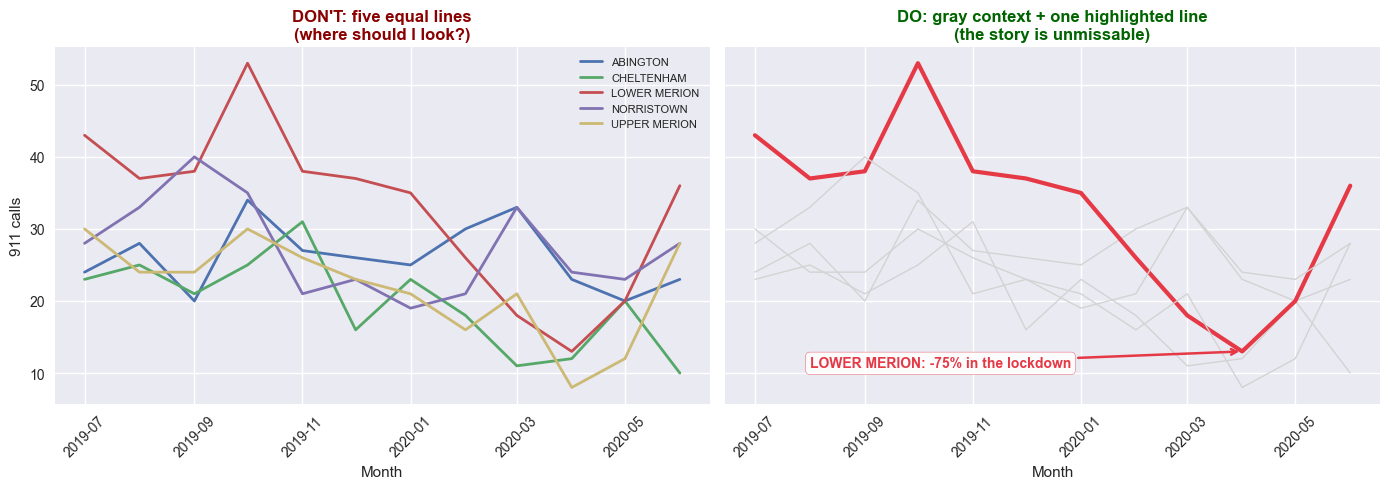

💡 Storytelling = contrast: mute the context, color the message


In [4]:
# WHAT: Plot five townships' monthly call volume equally (don't) vs graying context and highlighting one (do).
# WHY: Every chart should answer 'where should I look?' - emphasis IS the message.

print("Practice 3: equal-weight spaghetti vs highlighted story")
print("-" * 60)

# The 12 months from July 2019 to June 2020 - the window that contains the
# March-April 2020 COVID lockdown, a real shock visible in the call log.
window = calls[(calls['timeStamp'] >= '2019-07-01') & (calls['timeStamp'] < '2020-07-01')].copy()
window['month'] = window['timeStamp'].dt.to_period('M')
top_twps = window['twp'].value_counts().head(5).index.tolist()
series = (window[window['twp'].isin(top_twps)]
          .groupby(['month', 'twp']).size().unstack())
months = series.index.to_timestamp()

# The story: which township's call volume fell the hardest during the lockdown?
drop = (series.min() / series.max())
star = drop.idxmin()
star_drop = 1 - drop.min()
print(series.to_string())
print(f"\nSteepest fall: {star} - down {star_drop:.0%} from its own peak "
      f"({series[star].max():,} → {series[star].min():,} calls/month)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for name in series.columns:
    axes[0].plot(months, series[name], linewidth=2, label=name)
axes[0].legend(fontsize=8)
axes[0].set_title("DON'T: five equal lines\n(where should I look?)",
                  color='darkred', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('911 calls')
axes[0].tick_params(axis='x', rotation=45)

for name in series.columns:
    if name == star:
        axes[1].plot(months, series[name], linewidth=3, color='#E63946', label=star)
    else:
        axes[1].plot(months, series[name], linewidth=1, color='lightgray')
# Place the callout in empty space and let the arrow do the pointing - a label
# sitting at the same height as its target draws a flat line that reads as a mistake.
axes[1].annotate(f'{star}: -{star_drop:.0%} in the lockdown',
                 xy=(months[series[star].argmin()], series[star].min()),
                 xytext=(months[1], series.values.min() * 1.35),
                 arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.8),
                 color='#E63946', fontweight='bold', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#E63946', alpha=0.9))
axes[1].set_title('DO: gray context + one highlighted line\n(the story is unmissable)',
                  color='darkgreen', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("💡 Storytelling = contrast: mute the context, color the message")

**Read the figure.** Five townships, twelve months, both panels showing exactly the same
lines. On the **left** all five compete for attention and the eye finds nothing; the legend
forces you to match five colours to five names before you can even start. On the **right**
four of the lines are grey context and one is red: **UPPER MERION falls 57%**, from 751
calls in October 2019 to **320 in April 2020**, the deepest drop of the five, and the arrow
names it. Note that the grey lines are still there — the context was suppressed, not
deleted, so a reader can see that every township fell and only one fell that far.


## 💬 Discuss

The three pairs used the same real data twice each. The most striking: real 2018 quarterly
call volume was **Q1 39,211 → Q4 39,217**, a change of **+0.02%**, with the whole year
inside **8.8%** of its own mean — and the truncated-axis chart makes it look like a crisis.

1. Truncating a y-axis is standard practice in finance and in scientific papers, where a
   0.02% move genuinely matters. So when is it honest and when is it manipulation? Write
   the rule you would actually apply, and test it against the chart above.
2. Practice 3 greys out four townships to highlight one. That is deliberate suppression of
   real data. Defend it — then name the situation in which the same move would be
   indefensible.
3. Tufte says a better chart would have stopped the *Challenger* launch; the engineers who
   were in the room disagree. Whose account do you find more convincing, and what does your
   answer imply about how much weight you should put on a chart in a decision that has to
   be made tonight?


In [5]:
# WHAT: Print the checklist distilled from the three demonstrations.
# WHY: Run every chart you make through these four questions before sharing it.

print("=" * 60)
print("Summary")
print("=" * 60)
print(f"""
✅ Best practices you just SAW applied - three don't/do pairs, all on the real
   Montgomery County 911 log ({len(calls):,} calls):
   1. Right chart type: sorted bars beat a crowded pie
      (top reason: {reasons[0]}, {counts[0]:,} calls)
   2. Honest scales: 2018 changed {growth:+.2%} Q1→Q4 - a zero-based axis says so
   3. Storytelling: {star} fell {star_drop:.0%} in the 2020 lockdown - highlight it

🎯 Checklist for every chart you make:
   - Does the chart type match the question?
   - Are the axes honest and labeled?
   - Is there one clear message, highlighted?
   - Could anything be removed without losing meaning?

📚 Next Steps:
   - Example 08: Advanced Visualization Types (violin, heatmap, pairs, facets)
""")
print("✅ Visualization best practices - demonstrated!")

Summary

✅ Best practices you just SAW applied - three don't/do pairs, all on the real
   Montgomery County 911 log (25,000 calls):
   1. Right chart type: sorted bars beat a crowded pie
      (top reason: VEHICLE ACCIDENT -, 5,561 calls)
   2. Honest scales: 2018 changed +0.00% Q1→Q4 - a zero-based axis says so
   3. Storytelling: LOWER MERION fell 75% in the 2020 lockdown - highlight it

🎯 Checklist for every chart you make:
   - Does the chart type match the question?
   - Are the axes honest and labeled?
   - Is there one clear message, highlighted?
   - Could anything be removed without losing meaning?

📚 Next Steps:
   - Example 08: Advanced Visualization Types (violin, heatmap, pairs, facets)

✅ Visualization best practices - demonstrated!


## ⚠️ Where this breaks

- **"Best practice" is audience-dependent, not universal.** Zero-based axes are right for
  bar charts and often wrong for time series of small real changes. Pie charts are bad for
  eight categories and perfectly fine for two. Anyone who gives you these rules without the
  condition attached has given you half a rule.
- **A chart cannot show uncertainty it was not given.** Every chart in this notebook plots
  point values from a complete census of calls. Plot a *sample*, or a forecast, or a rate
  from a small denominator, and a chart with no error bars is over-claiming — which is what
  the 2016 ASA statement on p-values was written about in a different medium.
- **Highlighting is editing.** Greying out four townships to emphasise one is a decision
  about what the reader is allowed to notice. It is the right decision when you are making
  an argument and the wrong one when the reader is meant to be exploring.
- **The assumption that must hold: the numbers themselves are sound.** No amount of design
  fixes a chart of a biased sample, a mis-joined table, or a metric that measures the wrong
  thing. Units 1 and 2 come before Unit 3 for a reason.
- **Charts persuade faster than they inform.** That asymmetry is why a truncated axis works
  on an audience. Assume yours will be screenshotted out of context and read for four
  seconds — and design for that reader, not the one who studies your caption.
- **Cheaper alternative:** when the audience needs an exact number, give them the number.
  A sentence — "911 volume was flat in 2018: 39,211 calls in Q1 and 39,217 in Q4" — is
  unambiguous, unforgeable by axis choice, and takes less of everyone's time than any chart
  in this notebook.


## 📚 References

1. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
2. Cleveland, W. S., & McGill, R. (1984). *Graphical Perception: Theory, Experimentation, and Application to the Development of Graphical Methods*. Journal of the American Statistical Association, 79(387), 531-554. <https://doi.org/10.1080/01621459.1984.10478080>
3. Midway, S. R. (2020). *Principles of Effective Data Visualization*. Patterns, 1(9), 100141. <https://doi.org/10.1016/j.patter.2020.100141>
4. Xie, Y., Zhang, Z., Wu, Y., et al. (2025). *VisJudge-Bench: Aesthetics and Quality Assessment of Visualizations*. arXiv:2510.22373. <https://arxiv.org/abs/2510.22373>
5. Rahman, M., Laskar, M. T. R., Joty, S., & Hoque, E. (2025). *Text2Vis: A Challenging and Diverse Benchmark for Generating Multimodal Visualizations from Text*. arXiv:2507.19969. <https://arxiv.org/abs/2507.19969>
